In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
df=pd.read_csv("Friday-WorkingHours-Morning.pcap_ISCX.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [24]:
len(df)

191033

In [25]:
df.shape

(191033, 79)

In [26]:
df.columns=df.columns.str.strip()
print(df.columns[-1])

Label


In [27]:
df["Label"].value_counts()

Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64

In [28]:
df.dtypes.value_counts()

int64      54
float64    24
str         1
Name: count, dtype: int64

In [29]:
df.select_dtypes(include="str").columns

Index(['Label'], dtype='str')

In [30]:
y=df["Label"]
x=df.drop("Label",axis=1)



In [31]:
x.shape

(191033, 78)

In [32]:
x.isnull().sum().sum()

np.int64(28)

In [33]:
np.isinf(x).sum().sum()

np.int64(216)

In [34]:
from sklearn.ensemble import IsolationForest
iso_forest=IsolationForest(contamination=0.01,random_state=42)
pred=iso_forest.fit_predict(x)
pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [35]:
pd.Series(pred).value_counts()

 1    189122
-1      1911
Name: count, dtype: int64

In [36]:
re=df.copy()
re["pred"]=pred
re["pred"]=re["pred"].map({
    1:"BEGIGN",
    -1:"ANOMALY"
})
re[["Label","pred"]].head()

,Label,pred
0,BENIGN,BEGIGN
1,BENIGN,BEGIGN
2,BENIGN,BEGIGN
3,BENIGN,BEGIGN
4,BENIGN,BEGIGN


In [37]:
pd.crosstab(re["Label"],re["pred"])

pred,ANOMALY,BEGIGN
Label,,
BENIGN,1897,187170
Bot,14,1952


In [38]:
df.groupby("Label").mean(numeric_only=True).T.head(20)

Label,BENIGN,Bot
Destination Port,6.641397e+03,1.778399e+04
Flow Duration,1.176243e+07,3.509427e+05
Total Fwd Packets,1.393711e+01,3.193795e+00
Total Backward Packets,1.654962e+01,3.343845e+00
Total Length of Fwd Packets,5.786768e+02,2.645449e+03
Total Length of Bwd Packets,2.868015e+04,6.380010e+01
Fwd Packet Length Max,1.723192e+02,4.051963e+02
Fwd Packet Length Min,2.412279e+01,2.246185e+00
Fwd Packet Length Mean,5.123897e+01,1.132755e+02
Fwd Packet Length Std,4.946036e+01,1.207496e+02


In [39]:
x_clean=x.replace([np.inf,-np.inf],np.nan)
print(x_clean.isnull().sum().sum())

244


In [40]:
print(len(x_clean.columns))
print(x_clean.columns.to_list())

78
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Co

In [41]:
type(x_clean)

pandas.DataFrame

In [42]:
x_clean=x_clean.dropna()
y_clean=y.loc[x_clean.index]

In [43]:
x_clean.shape,y_clean.shape

((190911, 78), (190911,))

In [44]:
print(len(x_clean.columns))

78


In [45]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(x_clean)
x_scaled.shape

(190911, 78)

In [46]:
pred=iso_forest.fit_predict(x_scaled)
pd.Series(pred).value_counts()

 1    189001
-1      1910
Name: count, dtype: int64

In [47]:
results = pd.DataFrame({
    "Actual": y_clean,
    "Predicted": pred
})

results["Predicted"] = results["Predicted"].map({
    1: "BENIGN",
    -1: "ANOMALY"
})

pd.crosstab(
    results["Actual"],
    results["Predicted"]
)

Predicted,ANOMALY,BENIGN
Actual,,
BENIGN,1910,187045
Bot,0,1956


In [48]:
from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()
y_enc=enc.fit_transform(y_clean)
print(enc.classes_)

['BENIGN' 'Bot']


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_scaled,
    y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

print(X_train.shape)
print(X_test.shape)

(152728, 78)
(38183, 78)


In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
from sklearn.metrics import classification_report,confusion_matrix

y_pred = rf.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["BENIGN", "Bot"],
        digits=6
    )
)
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

      BENIGN   0.999312  1.000000  0.999656     37792
         Bot   1.000000  0.933504  0.965608       391

    accuracy                       0.999319     38183
   macro avg   0.999656  0.966752  0.982632     38183
weighted avg   0.999320  0.999319  0.999307     38183

[[37792     0]
 [   26   365]]


In [52]:
impo_df=pd.DataFrame({
    "feature":x_clean.columns,
    "importance":rf.feature_importances_
})
impo_df=impo_df.sort_values(by="importance",ascending=False)
impo_df.head(15)

,feature,importance
0,Destination Port,0.143897
66,Init_Win_bytes_forward,0.127234
67,Init_Win_bytes_backward,0.048567
15,Flow Packets/s,0.035314
16,Flow IAT Mean,0.033723
36,Fwd Packets/s,0.031430
1,Flow Duration,0.030694
29,Bwd IAT Min,0.027619
27,Bwd IAT Std,0.026412
26,Bwd IAT Mean,0.024392


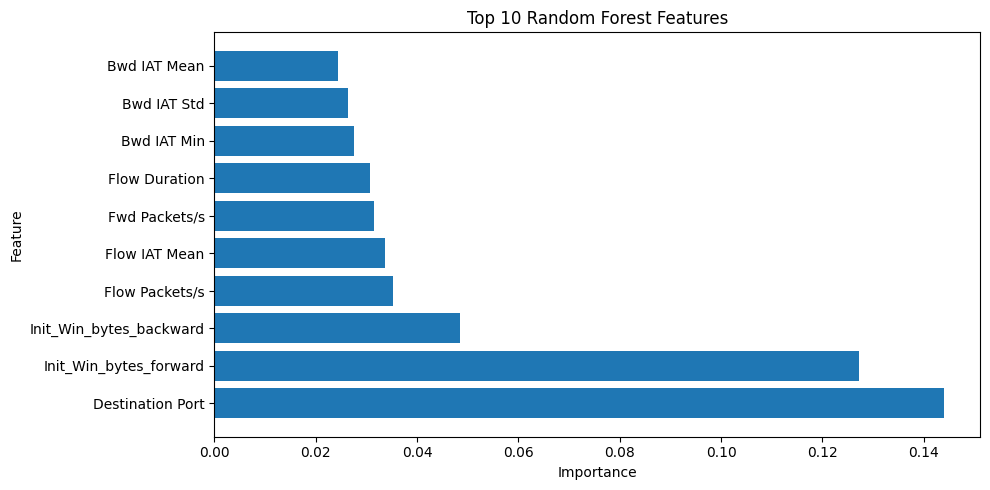

In [53]:
import matplotlib.pyplot as plt

top10 = impo_df.head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top10["feature"],
    top10["importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")
plt.tight_layout()
plt.show()

In [54]:
corr_matrix=x_clean.corr()
corr_matrix.shape

(78, 78)

In [55]:
high_corr_pairs=[]
for i in range (len(corr_matrix.columns)):
    for j in range(i+1,len(corr_matrix.columns)):
        corr=corr_matrix.iloc[i,j]
        if abs(corr)>0.95:
            high_corr_pairs.append((corr_matrix.columns[i],corr_matrix.columns[j],corr))
print(len(high_corr_pairs))

64


In [56]:
for p in high_corr_pairs[:20]:
    print(p)

('Flow Duration', 'Fwd IAT Total', np.float64(0.9977949252349729))
('Flow Duration', 'Bwd IAT Total', np.float64(0.9732949266519179))
('Total Fwd Packets', 'Total Backward Packets', np.float64(0.9995897889925365))
('Total Fwd Packets', 'Total Length of Bwd Packets', np.float64(0.9974687937604534))
('Total Fwd Packets', 'Fwd Header Length', np.float64(0.9988653402594833))
('Total Fwd Packets', 'Bwd Header Length', np.float64(0.9982571699890607))
('Total Fwd Packets', 'Fwd Header Length.1', np.float64(0.9988653402594833))
('Total Fwd Packets', 'Subflow Fwd Packets', np.float64(1.0))
('Total Fwd Packets', 'Subflow Bwd Packets', np.float64(0.9995897889925365))
('Total Fwd Packets', 'Subflow Bwd Bytes', np.float64(0.9974731799965156))
('Total Fwd Packets', 'act_data_pkt_fwd', np.float64(0.9964007176273132))
('Total Backward Packets', 'Total Length of Bwd Packets', np.float64(0.996235848552805))
('Total Backward Packets', 'Fwd Header Length', np.float64(0.998525656022313))
('Total Backward P

In [57]:
to_drop=set()
for f1,f2,corr in high_corr_pairs:
    to_drop.add(f2)
print(len(to_drop))

24


In [58]:
x_reduced=x_clean.drop(columns=list(to_drop))
x_reduced.shape

(190911, 54)

In [59]:
sc_reduced=StandardScaler()
x_reduced_scaled=sc_reduced.fit_transform(x_reduced)
x_reduced_scaled.shape

(190911, 54)

In [60]:
iso_forest=IsolationForest(contamination=0.01,random_state=42)
pred_reduced=iso_forest.fit_predict(x_reduced_scaled)
pred_reduced[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [61]:
pd.Series(pred_reduced).value_counts()

 1    189001
-1      1910
Name: count, dtype: int64

In [62]:
from sklearn.decomposition import  PCA
pca=PCA(n_components=2,random_state=42)
x_pca=pca.fit_transform(x_reduced_scaled)
print(pca.explained_variance_ratio_)

[0.2061337  0.13363436]


In [63]:
pca_df=pd.DataFrame({
    "pc1":x_pca[:,0],
    "pc2":x_pca[:,1],
    "label":y_clean.values
})
pca_df.head()

,pc1,pc2,label
0,2.390977,1.728311,BENIGN
1,2.533512,1.598629,BENIGN
2,4.726373,-0.217830,BENIGN
3,-1.378823,0.072268,BENIGN
4,-1.176142,0.101384,BENIGN


In [64]:
pca_df["label"].value_counts()

label
BENIGN    188955
Bot         1956
Name: count, dtype: int64

In [65]:
benign_sample = pca_df[pca_df["label"] == "BENIGN"].sample(
    n=5000,
    random_state=42
)

bot_sample = pca_df[pca_df["label"] == "Bot"]

plot_df = pd.concat(
    [benign_sample, bot_sample],
    axis=0
)

plot_df.shape

(6956, 3)

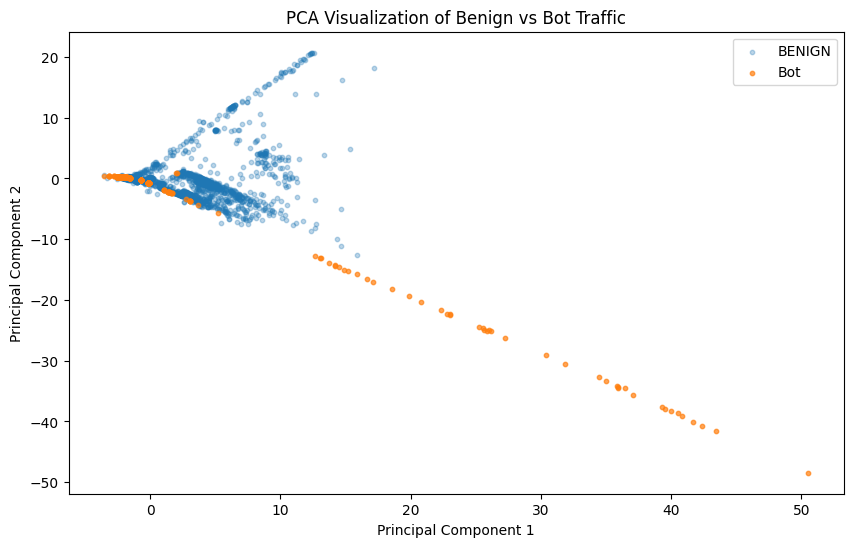

In [66]:


benign = plot_df[plot_df["label"] == "BENIGN"]
bot = plot_df[plot_df["label"] == "Bot"]

plt.figure(figsize=(10,6))

plt.scatter(
    benign["pc1"],
    benign["pc2"],
    alpha=0.3,
    s=10,
    label="BENIGN"
)

plt.scatter(
    bot["pc1"],
    bot["pc2"],
    alpha=0.7,
    s=10,
    label="Bot"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Benign vs Bot Traffic")
plt.legend()
plt.show()



In [67]:


iso_pca = IsolationForest(
    contamination=0.01,
    random_state=42
)

pred_pca = iso_pca.fit_predict(x_pca)

pd.Series(pred_pca).value_counts()

 1    189002
-1      1909
Name: count, dtype: int64

In [68]:
results_pca = pd.DataFrame({
    "Label": y_clean.values,
    "pred": pred_pca
})

pd.crosstab(
    results_pca["Label"],
    results_pca["pred"]
)

pred,-1,1
Label,,
BENIGN,1865,187090
Bot,44,1912


In [69]:
bot_mean = df[df["Label"] == "Bot"].mean(numeric_only=True)
benign_mean = df[df["Label"] == "BENIGN"].mean(numeric_only=True)

diff = abs(bot_mean - benign_mean)

diff.sort_values(ascending=False).head(20)

Flow Duration             1.141148e+07
Fwd IAT Total             1.113082e+07
Bwd IAT Total             1.016898e+07
Flow IAT Max              4.475395e+06
Fwd IAT Max               4.326589e+06
Idle Max                  4.079877e+06
Idle Mean                 3.947391e+06
Idle Min                  3.774375e+06
Bwd IAT Max               3.569366e+06
Fwd IAT Mean              2.008250e+06
Bwd IAT Mean              1.927741e+06
Flow IAT Std              1.622307e+06
Bwd IAT Min               1.322500e+06
Fwd IAT Min               1.289199e+06
Fwd IAT Std               1.142980e+06
Flow IAT Mean             9.127000e+05
Bwd IAT Std               8.300206e+05
Active Max                1.853009e+05
Idle Std                  1.768634e+05
Packet Length Variance    1.242766e+05
dtype: float64

In [70]:
important_features = [
    "Flow Duration",
    "Fwd IAT Total",
    "Bwd IAT Total",
    "Flow IAT Max",
    "Fwd IAT Max"
]

df.groupby("Label")[important_features].mean()

,Flow Duration,Fwd IAT Total,Bwd IAT Total,Flow IAT Max,Fwd IAT Max
Label,,,,,
BENIGN,1.176243e+07,1.147673e+07,1.051914e+07,4.648060e+06,4.499973e+06
Bot,3.509427e+05,3.459039e+05,3.501617e+05,1.726650e+05,1.733834e+05


In [71]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [72]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_dt,
        target_names=["BENIGN", "Bot"]
    )
)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     37792
         Bot       0.99      0.97      0.98       391

    accuracy                           1.00     38183
   macro avg       0.99      0.99      0.99     38183
weighted avg       1.00      1.00      1.00     38183



In [73]:
cm_dt=confusion_matrix(y_test,pred_dt) 
print(cm_dt)

[[37788     4]
 [   11   380]]


In [74]:
comparison = {
    "Model": ["Isolation Forest", "Random Forest", "Decision Tree"],
    "Bot Recall": [44/1956, 365/391, 380/391]
}

import pandas as pd

pd.DataFrame(comparison)

,Model,Bot Recall
0,Isolation Forest,0.022495
1,Random Forest,0.933504
2,Decision Tree,0.971867


In [75]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=42,eval_metric="logloss")
xgb.fit(X_train,y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [76]:
pred_xgb=xgb.predict(X_test)

In [77]:

print(
    classification_report(
        y_test,
        pred_xgb,
        target_names=["BENIGN", "Bot"]
    )
)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     37792
         Bot       0.99      1.00      0.99       391

    accuracy                           1.00     38183
   macro avg       0.99      1.00      1.00     38183
weighted avg       1.00      1.00      1.00     38183



In [78]:
print(confusion_matrix(y_test,pred_xgb))

[[37788     4]
 [    1   390]]


In [79]:
import joblib
joblib.dump(xgb,"xgboost_bot_detector.pkl")


['xgboost_bot_detector.pkl']

In [80]:
##import tensorflow as tf

In [81]:
x_benign=x_clean[y_clean=="BENIGN"]
sc_ae=StandardScaler()
x_benign_scaled=sc_ae.fit_transform(x_benign)
x_benign.shape

(188955, 78)

In [82]:
from sklearn.model_selection import train_test_split

X_train_ae, X_val_ae = train_test_split(
    x_benign_scaled,
    test_size=0.2,
    random_state=42
)

print(X_train_ae.shape)
print(X_val_ae.shape)

(151164, 78)
(37791, 78)


In [83]:
'''from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train_ae.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)
encoded = Dense(8, activation="relu")(encoded)

# Decoder
decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()'''

'from tensorflow.keras.models import Model\nfrom tensorflow.keras.layers import Input, Dense\n\ninput_dim = X_train_ae.shape[1]\n\ninput_layer = Input(shape=(input_dim,))\n\n# Encoder\nencoded = Dense(32, activation="relu")(input_layer)\nencoded = Dense(16, activation="relu")(encoded)\nencoded = Dense(8, activation="relu")(encoded)\n\n# Decoder\ndecoded = Dense(16, activation="relu")(encoded)\ndecoded = Dense(32, activation="relu")(decoded)\ndecoded = Dense(input_dim, activation="linear")(decoded)\n\nautoencoder = Model(inputs=input_layer, outputs=decoded)\n\nautoencoder.compile(\n    optimizer="adam",\n    loss="mse"\n)\n\nautoencoder.summary()'

In [84]:
'''history = autoencoder.fit(
    X_train_ae,
    X_train_ae,
    epochs=10,
    batch_size=256,
    validation_data=(X_val_ae, X_val_ae),
    verbose=1
)'''

'history = autoencoder.fit(\n    X_train_ae,\n    X_train_ae,\n    epochs=10,\n    batch_size=256,\n    validation_data=(X_val_ae, X_val_ae),\n    verbose=1\n)'

In [85]:
'''val_pred=autoencoder.predict(X_val_ae)
val_mse=np.mean(np.square(X_val_ae-val_pred),axis=1)
print(val_mse[:10])
print("mean:",val_mse.mean())
print("std:",val_mse.std())'''

'val_pred=autoencoder.predict(X_val_ae)\nval_mse=np.mean(np.square(X_val_ae-val_pred),axis=1)\nprint(val_mse[:10])\nprint("mean:",val_mse.mean())\nprint("std:",val_mse.std())'

In [86]:
##np.percentile(val_mse,[50,90,95,99,99.5,99.9])

In [87]:
x_all_scaled=sc_ae.transform(x_clean)
x_all_scaled.shape

(190911, 78)

In [88]:
##all_pred=autoencoder.predict(x_all_scaled)

In [89]:
'''all_mse=np.mean(np.square(x_all_scaled-all_pred),axis=1)
print(all_mse[:10])
print("mean:",all_mse.mean())
print("std:",all_mse.std())'''

'all_mse=np.mean(np.square(x_all_scaled-all_pred),axis=1)\nprint(all_mse[:10])\nprint("mean:",all_mse.mean())\nprint("std:",all_mse.std())'

In [90]:
'''threshold=0.81662188
ae_pred=np.where(all_mse>threshold,"Bot","BENIGN")
pd.Series(ae_pred).value_counts()'''

'threshold=0.81662188\nae_pred=np.where(all_mse>threshold,"Bot","BENIGN")\npd.Series(ae_pred).value_counts()'

In [91]:
##print(classification_report(y_clean,ae_pred))

In [92]:
##print(confusion_matrix(y_clean,ae_pred))

In [93]:
importance = pd.DataFrame({
    "Feature": x_clean.columns,
    "Importance": xgb.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
29,Bwd IAT Min,0.755489
34,Fwd Header Length,0.080049
10,Bwd Packet Length Max,0.066343
46,PSH Flag Count,0.033590
66,Init_Win_bytes_forward,0.016583
27,Bwd IAT Std,0.008164
0,Destination Port,0.007765
22,Fwd IAT Std,0.006300
48,URG Flag Count,0.005153
40,Packet Length Mean,0.003693


In [94]:
print(x_clean.shape)
print(y_clean.value_counts())

(190911, 78)
Label
BENIGN    188955
Bot         1956
Name: count, dtype: int64


In [95]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_encoded=le.fit_transform(y_clean)
print(le.classes_)
print(pd.Series(y_encoded).value_counts())

['BENIGN' 'Bot']
0    188955
1      1956
Name: count, dtype: int64


In [96]:
x_train_lstm,x_test_lstm,y_train_lstm,y_test_lstm=train_test_split(x_clean,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)
print(x_train_lstm.shape)
print(x_test_lstm.shape)

(152728, 78)
(38183, 78)


In [97]:
from sklearn.utils.class_weight import compute_class_weight
class_weights=compute_class_weight(class_weight="balanced",classes=np.unique(y_train_lstm),y=y_train_lstm)
class_weight_dict={
    0:class_weights[0],
    1:class_weights[1]
}
print(class_weight_dict)


{0: np.float64(0.5051765312940336), 1: np.float64(48.79488817891374)}


In [98]:
scaler_lstm=StandardScaler()
x_train_lstm_scaled=scaler_lstm.fit_transform(x_train_lstm)
x_test_lstm_scaled=scaler_lstm.transform(x_test_lstm)
print(x_train_lstm_scaled.shape)
print(x_test_lstm_scaled.shape)

(152728, 78)
(38183, 78)


In [99]:
x_train_lstm_scaled=x_train_lstm_scaled.reshape(x_train_lstm_scaled.shape[0],x_train_lstm_scaled.shape[1],1)
x_test_lstm_scaled=x_test_lstm_scaled.reshape(x_test_lstm_scaled.shape[0],x_test_lstm_scaled.shape[1],1)
print(x_train_lstm_scaled.shape)
print(x_test_lstm_scaled.shape)


(152728, 78, 1)
(38183, 78, 1)


In [100]:
'''from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout
lstm_model=Sequential([
    LSTM(64,input_shape=(78,1)),
    Dropout(0.2),
    Dense(32,activation="relu"),
    Dense(1,activation="sigmoid")
])
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
lstm_model.summary()'''

'from tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import LSTM,Dense,Dropout\nlstm_model=Sequential([\n    LSTM(64,input_shape=(78,1)),\n    Dropout(0.2),\n    Dense(32,activation="relu"),\n    Dense(1,activation="sigmoid")\n])\nlstm_model.compile(\n    optimizer="adam",\n    loss="binary_crossentropy",\n    metrics=["accuracy"]\n)\nlstm_model.summary()'

In [101]:
##history=lstm_model.fit(x_test_lstm_scaled,y_train_lstm,epochs=5,batch_size=256,validation_split=0.2,verbose=1,class_weight=class_weight_dict)

In [102]:
##y_pred_lstm=lstm_model.predict(x_test_lstm_scaled)
##print(y_pred_lstm[:10])

In [103]:
deployment_features = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'Average Packet Size'
]

print(len(deployment_features))

for col in deployment_features:
    print(col, "->", col in x_clean.columns)

15
Destination Port -> True
Flow Duration -> True
Total Fwd Packets -> True
Total Backward Packets -> True
Total Length of Fwd Packets -> True
Total Length of Bwd Packets -> True
Flow Bytes/s -> True
Flow Packets/s -> True
Packet Length Mean -> True
Packet Length Std -> True
SYN Flag Count -> True
ACK Flag Count -> True
RST Flag Count -> True
PSH Flag Count -> True
Average Packet Size -> True


In [107]:
x_deploy=x_clean[deployment_features]
x_deploy.shape
le_dep=LabelEncoder()
y_dep=le_dep.fit_transform(y_clean)

In [108]:
from sklearn.model_selection import  train_test_split
x_train_dep,x_test_dep,y_train_dep,y_test_dep=train_test_split(x_deploy,y_dep,test_size=0.2,random_state=42,stratify=y_dep)
print(x_train_dep.shape)
print(x_test_dep.shape)

(152728, 15)
(38183, 15)


In [109]:
xgb_ids=XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=42,eval_metric="logloss")
xgb_ids.fit(x_train_dep,y_train_dep)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [111]:
y_pred_dep=xgb_ids.predict(x_test_dep)
print(classification_report(y_test_dep,y_pred_dep))
print(confusion_matrix(y_test_dep,y_pred_dep))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     37792
           1       0.97      0.72      0.83       391

    accuracy                           1.00     38183
   macro avg       0.98      0.86      0.91     38183
weighted avg       1.00      1.00      1.00     38183

[[37784     8]
 [  109   282]]


In [113]:
joblib.dump(xgb_ids,"xgboost_ids_model.pkl")
joblib.dump(deployment_features,"deployment_features.pkl")

['deployment_features.pkl']